# Problema 2. Deteccion probabilistica de fallas en fabricacion de semiconductores

Dato de entrada: SECOM (UCI, id 179), 1567 observaciones y 590 variables de proceso, con clase de fallo minoritaria.

Parametro: media y covarianza de cada clase, estimadas por maxima verosimilitud.

Modelo: clasificador generativo gaussiano con tres familias de covarianza, completa, diagonal y contraida.

Salida verificable: matriz de confusion, curva precision recall, log verosimilitud de prueba, condicion numerica de la covarianza y superficie de error frente a n y d.

---

## Como leer este cuaderno

Cada bloque de codigo va precedido por una celda que explica que hace, paso a paso, y con que idea del capitulo 3 de Duda, Hart y Stork (*Pattern Classification*, 2.ª ed.) se conecta. Despues de las salidas importantes hay una celda de lectura.

El problema es el mas cercano al planteamiento original del capitulo: hay dos clases (lote conforme y lote con fallo), se supone que dentro de cada clase las variables de proceso siguen una normal multivariante $\mathcal{N}_d(\mu_c, \Sigma_c)$, se estiman $\mu_c$ y $\Sigma_c$ por maxima verosimilitud y se clasifica con la regla de Bayes. Lo que lo hace interesante es la dimension: 590 variables y apenas un centenar de lotes con fallo. Con $d$ grande y $n$ pequeno la covarianza completa tiene mas parametros que datos para estimarlos, y el capitulo dedica la seccion 3.7 exactamente a ese problema. El cuaderno muestra con numeros lo que alli se dice con palabras: un modelo mas flexible no es un modelo mejor.

## Mapa entre el cuaderno y el capitulo 3

| Seccion del cuaderno | Idea del capitulo | Donde esta en el libro |
|---|---|---|
| 4. Preprocesamiento con estadisticas de entrenamiento | Toda estimacion sale de la muestra de entrenamiento; la prueba mide generalizacion | 3.1 y 3.7.3 |
| 5. Modelo gaussiano generativo | MLE de $\mu$ y $\Sigma$ en la normal multivariante; funcion discriminante $g_c(x)$ | 3.2.3, y 2.6 para la forma de $g_c$ |
| 5. Distancia de Mahalanobis y Cholesky | $(x-\mu)^\top\Sigma^{-1}(x-\mu)$ calculada sin invertir $\Sigma$; complejidad computacional | 2.6 y 3.7.2 |
| 7. Covarianza completa | Cuando $n < d$, $\hat\Sigma$ es singular y la verosimilitud no se puede evaluar | 3.7.1 y 3.7.3 |
| 8. Contraccion de la covarianza | *Shrinkage*: $\Sigma_\lambda = (1-\lambda)\hat\Sigma + \lambda D$ como remedio al sobreajuste | 3.7.3 |
| 9 y 10. Comparacion de familias, superficie $n$ frente a $d$ | Precision, dimension y tamano de muestra: agregar variables puede empeorar el clasificador | 3.7.1 |
| 11. Umbral sensible al costo | Riesgo de Bayes con costos asimetricos | 2.2 |
| 13. Diagnostico | Normalidad por clase, igualdad de covarianzas (frontera lineal frente a cuadratica) | 2.6 y 3.7 |

## Notacion

$x \in \mathbb{R}^d$ es el vector de variables de proceso de un lote, $y \in \{0, 1\}$ su clase (1 es fallo). $\mu_c$ y $\Sigma_c$ son la media y la covarianza de la clase $c$; $\hat\mu_c$ y $\hat\Sigma_c$ sus estimaciones por maxima verosimilitud. $n_c$ es el numero de lotes de la clase $c$ en entrenamiento. $L$ es el factor de Cholesky, la matriz triangular inferior tal que $\Sigma = LL^\top$. $\lambda$ es el parametro de contraccion.

**Que hace esta celda.** Instala las librerias. La unica que no aparecio en el problema 1 es `scipy`, de la que se usa una sola funcion, `solve_triangular`, para resolver sistemas con matrices triangulares de forma eficiente. El clasificador, las metricas y la validacion se programan a mano para que cada formula del capitulo sea visible.

In [1]:
!pip install ucimlrepo numpy pandas matplotlib scipy

**Que hace esta celda.** Importa las librerias, fija la semilla `SEED = 7` para que la particion aleatoria sea reproducible, y configura la presentacion de tablas y figuras. `solve_triangular` se usara en la seccion 5 para calcular la distancia de Mahalanobis a partir del factor de Cholesky.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve_triangular
from ucimlrepo import fetch_ucirepo

SEED = 7
rng = np.random.default_rng(SEED)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (11, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

## 1. Carga

La etiqueta original usa -1 para lote conforme y 1 para fallo. Se recodifica a 0 y 1.

**Que hace esta celda.** Carga SECOM. La celda intenta dos fuentes, en orden:

1. El repositorio de UCI en linea, a traves de `ucimlrepo`. Algunas versiones de esa libreria devuelven el conjunto sin la columna de etiquetas (`targets` vacio), que fue lo que ocurrio en la primera version de este cuaderno; por eso la celda comprueba que la etiqueta exista y, si viene dentro de `features`, la separa.
2. Los archivos originales de UCI en una carpeta local: `secom.data` con las 590 variables separadas por espacios, y `secom_labels.data` con la etiqueta en la primera columna (y una marca de tiempo que no se usa). Se buscan en `datos/secom/` y en `data/secom/`.

El resultado son `X_bruto`, una tabla de 1567 filas por 590 columnas, y `y_bruto`, la etiqueta original, que vale $-1$ para lote conforme y $1$ para fallo.

**Conexion con el libro.** Como en el problema 1, esta celda trae la muestra etiquetada $D = D_1 \cup D_2$ del planteamiento de la seccion 3.1. El capitulo supone que las muestras de una clase no dicen nada sobre los parametros de la otra, asi que el problema de dos clases se resuelve como dos problemas de estimacion independientes, uno por clase.

In [3]:
from pathlib import Path


def cargar_secom():
    # Fuente 1: repositorio UCI en linea. Se verifica que la etiqueta venga
    # separada; algunas versiones de ucimlrepo la devuelven dentro de features.
    try:
        secom = fetch_ucirepo(id=179)
        Xb, yb = secom.data.features, secom.data.targets
        if yb is None:
            etiqueta = [c for c in Xb.columns
                        if str(c).strip().lower() in ("pass/fail", "pass_fail", "class", "label", "target")]
            if etiqueta:
                yb = Xb[etiqueta]
                Xb = Xb.drop(columns=etiqueta)
        if yb is not None:
            Xb = Xb.select_dtypes(include=[np.number])
            return Xb, yb, "UCI en linea (ucimlrepo)"
    except Exception:
        pass
    # Fuente 2: archivos originales de UCI en una carpeta local.
    for carpeta in [Path("datos/secom"), Path("data/secom"), Path("datos"), Path("data")]:
        if (carpeta / "secom.data").exists() and (carpeta / "secom_labels.data").exists():
            Xb = pd.read_csv(carpeta / "secom.data", sep=r"\s+", header=None)
            Xb.columns = [f"v{j}" for j in range(Xb.shape[1])]
            yb = pd.read_csv(carpeta / "secom_labels.data", sep=r"\s+", header=None,
                             engine="python").iloc[:, [0]]
            yb.columns = ["Pass/Fail"]
            return Xb, yb, f"archivos locales en {carpeta}"
    raise FileNotFoundError("No se encontro SECOM ni en linea ni en datos/secom o data/secom")


X_bruto, y_bruto, ORIGEN = cargar_secom()

pd.Series({"origen": ORIGEN, "filas": X_bruto.shape[0], "variables": X_bruto.shape[1],
           "columna de etiqueta": y_bruto.columns[0]})

origen                 archivos locales en datos/secom
filas                                             1567
variables                                          590
columna de etiqueta                          Pass/Fail
dtype: object

**Que hace esta celda.** Recodifica la etiqueta a $y = 1$ para fallo y $y = 0$ para conforme, convierte la tabla de variables en una matriz de numpy de tipo flotante (los faltantes quedan como `NaN`) y guarda los nombres de las columnas. La tabla resume cuantos lotes hay de cada clase.

**Como leer la salida.** Hay 104 fallos entre 1567 lotes, el 6,6 %. Ese numero, y no el total, es el que limita todo lo que sigue: la clase de fallo tiene un centenar de observaciones para estimar una media de 590 componentes y una covarianza de $590 \times 591 / 2 = 174\,345$ parametros.

In [4]:
y = (y_bruto.to_numpy().ravel() == 1).astype(int)
X = X_bruto.to_numpy(dtype=float)
nombres = np.array(X_bruto.columns.tolist())

pd.Series({"observaciones": X.shape[0], "variables": X.shape[1],
           "fallos": int(y.sum()), "conformes": int((1 - y).sum()),
           "proporcion de fallo": float(y.mean())}).round(4)

observaciones          1567.0000
variables               590.0000
fallos                  104.0000
conformes              1463.0000
proporcion de fallo       0.0664
dtype: float64

## 2. Auditoria de variables

Se cuantifica el faltante por columna y se identifican las columnas constantes o casi constantes. La eliminacion se aplica mas adelante usando solo el conjunto de entrenamiento.

**Que hace esta celda.** Audita cada columna antes de tocar nada. Para cada una de las 590 variables calcula la proporcion de faltantes, el numero de valores distintos (ignorando faltantes) y la varianza. Luego resume cuantas columnas son constantes (un solo valor), casi constantes (dos o menos), cuantas tienen mas de la mitad de faltantes y cuantas estan completas.

**Por que importa para el modelo.** Una columna constante tiene varianza cero, y una covarianza con un cero en la diagonal es singular: no tiene inversa y su determinante es cero, con lo que la densidad gaussiana de la seccion 3.2.3 no se puede evaluar. Detectarlas antes es parte de hacer estimable el modelo. La eliminacion no se aplica aqui todavia: la seccion 4 la hace con las estadisticas del bloque de entrenamiento, para que la decision de que columnas conservar no use informacion de la prueba.

In [5]:
faltante = np.isnan(X).mean(axis=0)
distintos = np.array([len(np.unique(X[~np.isnan(X[:, j]), j])) for j in range(X.shape[1])])
varianza = np.nanvar(X, axis=0)

auditoria = pd.DataFrame({"variable": nombres, "faltante": faltante,
                          "valores distintos": distintos, "varianza": varianza})

pd.Series({"columnas": X.shape[1],
           "constantes": int((distintos <= 1).sum()),
           "casi constantes (2 o menos valores)": int((distintos <= 2).sum()),
           "con mas de 50 por ciento faltante": int((faltante > 0.50).sum()),
           "sin ningun faltante": int((faltante == 0).sum()),
           "faltante total": float(faltante.mean())}).round(4)

columnas                               590.0000
constantes                             116.0000
casi constantes (2 o menos valores)    122.0000
con mas de 50 por ciento faltante       28.0000
sin ningun faltante                     52.0000
faltante total                           0.0454
dtype: float64

**Como leer la salida.** De 590 columnas, 116 son constantes y 122 tienen dos o menos valores distintos; 28 tienen mas de la mitad de faltantes y solo 52 estan completas. El faltante total es 4,5 %. Las constantes son las que harian singular a cualquier covarianza y se retiran en la seccion 4.

**Que hace esta celda.** Dos histogramas: la proporcion de faltantes por columna y el logaritmo de la varianza por columna. El segundo muestra que las variables viven en escalas muy distintas (varias decenas de ordenes de magnitud), lo que justifica la estandarizacion de la seccion 4: sin ella, la distancia de Mahalanobis quedaria dominada numericamente por las columnas de mayor varianza y el calculo seria inestable.

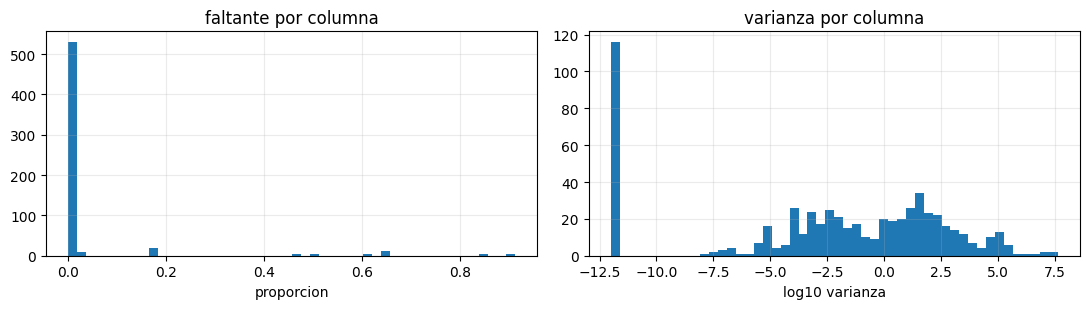

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(faltante, bins=50)
ax[0].set_title("faltante por columna"); ax[0].set_xlabel("proporcion")
ax[1].hist(np.log10(varianza + 1e-12), bins=50)
ax[1].set_title("varianza por columna"); ax[1].set_xlabel("log10 varianza")
fig.tight_layout()

## 3. Particion estratificada

Sesenta, veinte y veinte por ciento para entrenamiento, validacion y prueba, preservando la proporcion de la clase minoritaria en los tres bloques.

**Que hace esta celda.** Parte el conjunto en tres bloques, 60 % entrenamiento, 20 % validacion y 20 % prueba, preservando la proporcion de fallos en cada uno. La funcion recorre cada clase por separado, baraja sus indices con la semilla y los reparte segun las proporciones; al final ordena los indices de cada bloque.

**Por que tres bloques y no dos.** El cuaderno tiene un hiperparametro que elegir, $\lambda$. Si se eligiera mirando el bloque de prueba, la precision reportada en prueba estaria inflada, porque $\lambda$ se habria ajustado a ese bloque. Validacion sirve para elegir, prueba sirve para reportar, y ninguno de los dos participa en la estimacion de $\mu_c$ y $\Sigma_c$. Es la separacion entre ajuste y evaluacion que el capitulo introduce al hablar de sobreajuste en la seccion 3.7.3.

**Por que estratificada.** Con 104 fallos, un reparto aleatorio simple podria dejar 15 en un bloque y 30 en otro por azar, y las metricas de la clase minoritaria serian incomparables entre bloques.

In [7]:
def particion_estratificada(y, proporciones=(0.60, 0.20, 0.20), semilla=SEED):
    gen = np.random.default_rng(semilla)
    idx = {0: [], 1: [], 2: []}
    for c in np.unique(y):
        pos = np.flatnonzero(y == c)
        gen.shuffle(pos)
        c1 = int(proporciones[0] * len(pos))
        c2 = c1 + int(proporciones[1] * len(pos))
        idx[0].append(pos[:c1]); idx[1].append(pos[c1:c2]); idx[2].append(pos[c2:])
    return tuple(np.sort(np.concatenate(idx[k])) for k in range(3))

i_tr, i_va, i_te = particion_estratificada(y)

pd.DataFrame({"bloque": ["entrenamiento", "validacion", "prueba"],
              "n": [len(i_tr), len(i_va), len(i_te)],
              "fallos": [int(y[i].sum()) for i in (i_tr, i_va, i_te)],
              "proporcion de fallo": [float(y[i].mean()) for i in (i_tr, i_va, i_te)]}).round(4)

,bloque,n,fallos,proporcion de fallo
0,entrenamiento,939,62,0.0660
1,validacion,312,20,0.0641
2,prueba,316,22,0.0696


## 4. Preprocesamiento con estadisticas de entrenamiento

Se descartan las columnas constantes o con demasiado faltante segun el bloque de entrenamiento, se imputa con la mediana de entrenamiento y se estandariza con media y desviacion de entrenamiento. Ningun estadistico proviene de validacion ni de prueba.

**Que hace esta celda.** Aplica tres transformaciones, todas aprendidas en el bloque de entrenamiento y aplicadas a los tres bloques.

1. *Filtrado de columnas.* Se conservan las variables con 40 % o menos de faltantes y al menos tres valores distintos, calculado solo con `Xtr_bruto`. La mascara `conservar` se aplica igual a validacion y prueba.
2. *Imputacion.* Cada faltante se reemplaza por la mediana de entrenamiento de su columna. `np.take(mediana_tr, np.where(faltan)[1])` toma, para cada celda faltante, la mediana de la columna correspondiente.
3. *Estandarizacion.* Se resta la media y se divide por la desviacion de entrenamiento. Si una desviacion fuera cero se reemplaza por uno para no dividir por cero.

La tabla final muestra cuantas variables quedan ($d$), cuantos lotes de entrenamiento hay ($n$), cuantos de ellos son fallos, y cuantos parametros tendria una covarianza completa con ese $d$.

**Conexion con el libro.** La razon por la que ningun estadistico puede salir de validacion o prueba es la misma por la que el capitulo insiste en distinguir la muestra de entrenamiento del resto: la probabilidad de error que interesa es la de datos nuevos, y un preprocesamiento que "vio" esos datos hace que ya no sean nuevos. El numero de parametros de la covarianza, $d(d+1)/2$, comparado con $n$, es el cociente que la seccion 3.7.1 identifica como el que gobierna la calidad de la estimacion.

In [8]:
MAX_FALTANTE = 0.40
MIN_DISTINTOS = 3

Xtr_bruto = X[i_tr]
faltante_tr = np.isnan(Xtr_bruto).mean(axis=0)
distintos_tr = np.array([len(np.unique(Xtr_bruto[~np.isnan(Xtr_bruto[:, j]), j]))
                         for j in range(Xtr_bruto.shape[1])])

conservar = (faltante_tr <= MAX_FALTANTE) & (distintos_tr >= MIN_DISTINTOS)

mediana_tr = np.nanmedian(Xtr_bruto[:, conservar], axis=0)

def preparar(bloque):
    Z = X[bloque][:, conservar].copy()
    faltan = np.isnan(Z)
    Z[faltan] = np.take(mediana_tr, np.where(faltan)[1])
    return Z

Ztr, Zva, Zte = preparar(i_tr), preparar(i_va), preparar(i_te)

media_tr = Ztr.mean(axis=0)
sd_tr = Ztr.std(axis=0, ddof=0)
sd_tr[sd_tr == 0] = 1.0

Ztr = (Ztr - media_tr) / sd_tr
Zva = (Zva - media_tr) / sd_tr
Zte = (Zte - media_tr) / sd_tr

ytr, yva, yte = y[i_tr], y[i_va], y[i_te]

pd.Series({"variables originales": X.shape[1],
           "variables conservadas": int(conservar.sum()),
           "d": Ztr.shape[1],
           "n entrenamiento": Ztr.shape[0],
           "n de la clase fallo en entrenamiento": int(ytr.sum()),
           "parametros de una covarianza completa": int(Ztr.shape[1] * (Ztr.shape[1] + 1) / 2)})

variables originales                       590
variables conservadas                      436
d                                          436
n entrenamiento                            939
n de la clase fallo en entrenamiento        62
parametros de una covarianza completa    95266
dtype: int64

**Como leer la salida.** Quedan $d = 436$ variables y $n = 939$ lotes de entrenamiento, de los cuales solo 62 son fallos. Una covarianza completa tiene 95.266 parametros. Para la clase conforme hay 877 filas, ya de por si pocas para 95 mil parametros; para la clase de fallo hay 62 filas, menos que la dimension. La seccion 7 muestra la consecuencia.

## 5. Modelo gaussiano generativo

$$X \mid Y = c \sim \mathcal{N}_d(\mu_c, \Sigma_c)$$

$$g_c(x) = -\tfrac{1}{2}\log|\Sigma_c| - \tfrac{1}{2}(x-\mu_c)^{\top}\Sigma_c^{-1}(x-\mu_c) + \log P(Y=c)$$

$$d_M^2(x, \mu_c) = (x-\mu_c)^{\top}\Sigma_c^{-1}(x-\mu_c)$$

Familias de covarianza comparadas:

- completa, con $d(d+1)/2$ parametros por clase
- diagonal, con $d$ parametros por clase
- contraida, $\Sigma_\lambda = (1-\lambda)\hat\Sigma + \lambda D$, con $D$ diagonal o proporcional a la identidad

El log determinante y la distancia de Mahalanobis se obtienen de la factorizacion de Cholesky. No se invierte ninguna matriz de forma explicita.

**Que hace esta celda.** Define las piezas del clasificador gaussiano. Conviene leerlas en el orden en que se usan.

`covarianza_familia(S, tipo, lam, destino)` recibe la covarianza muestral $S$ y devuelve la version de la familia elegida: la misma matriz (completa), solo su diagonal (diagonal), o la combinacion convexa $(1-\lambda)S + \lambda D$ (contraida), donde $D$ es la diagonal de $S$ o un multiplo de la identidad con la misma traza.

`cholesky_segura(S)` calcula el factor de Cholesky $L$ tal que $S = LL^\top$. Si $S$ no es definida positiva (por ejemplo porque $n < d$), numpy lanza un error; la funcion reintenta sumando a la diagonal una cantidad `jitter` que crece por diez en cada intento y devuelve cuantos "saltos" necesito. Ese numero es un termometro de lo mal condicionada que esta la matriz: cero saltos es una covarianza sana, doce es una que solo se pudo factorizar despues de perturbarla mucho.

`log_densidad(Z, mu, L)` evalua $\log p(x \mid c)$ para todas las filas de `Z` sin invertir $\Sigma$. La distancia de Mahalanobis $(x-\mu)^\top\Sigma^{-1}(x-\mu)$ se obtiene resolviendo el sistema triangular $La = x - \mu$ y sumando $a^\top a$, porque $\Sigma^{-1} = L^{-\top}L^{-1}$. El log determinante es $2\sum_i \log L_{ii}$. Devuelve tambien la propia distancia.

`ajustar(Ztr, ytr, tipo, ...)` es la estimacion por maxima verosimilitud, clase por clase: $\hat\mu_c$ es la media de las filas de la clase y $S$ es la covarianza muestral (con $n_c - 1$ en el denominador, la variante insesgada que el capitulo discute al final de la seccion 3.2.3). Guarda tambien $\log P(c)$, estimado por la frecuencia de la clase en entrenamiento.

`log_posterior(modelo, Z)` calcula $\log P(y = 1 \mid x) - \log P(y = 0 \mid x)$, es decir, el logaritmo del cociente de posteriores. Suma la log densidad y el log de la previa de cada clase (eso es $g_c(x)$), y normaliza con el truco del maximo (`logZ`) para no desbordar al exponenciar. Un valor positivo significa que la posterior de fallo supera 0,5.

`log_verosimilitud_media` promedia $\log p(x \mid y)$ sobre un bloque usando la clase verdadera de cada fila. Mide que tan bien describe el modelo generativo a los datos, con independencia de si clasifica bien.

**Conexion con el libro.** Las formulas de `ajustar` son las de la seccion 3.2.3: el MLE de la media de una normal multivariante es la media muestral y el de la covarianza es $\frac{1}{n}\sum (x_k - \hat\mu)(x_k - \hat\mu)^\top$. La funcion discriminante $g_c(x) = -\frac{1}{2}\log|\Sigma_c| - \frac{1}{2}(x-\mu_c)^\top\Sigma_c^{-1}(x-\mu_c) + \log P(c)$ es la del caso general de la seccion 2.6 (covarianzas distintas por clase, frontera cuadratica), con los parametros sustituidos por sus estimaciones, que es exactamente lo que la seccion 3.2 propone hacer. Evitar la inversa explicita y usar Cholesky responde a la seccion 3.7.2 sobre complejidad computacional: invertir cuesta $O(d^3)$ y es numericamente peor que factorizar y resolver.

In [9]:
def covarianza_familia(S, tipo, lam=0.0, destino="diagonal"):
    d = S.shape[0]
    if tipo == "completa":
        return S.copy()
    if tipo == "diagonal":
        return np.diag(np.diag(S))
    if tipo == "contraida":
        D = np.diag(np.diag(S)) if destino == "diagonal" else (np.trace(S) / d) * np.eye(d)
        return (1.0 - lam) * S + lam * D
    raise ValueError(tipo)


def cholesky_segura(S, jitter=1e-10, intentos=12):
    d = S.shape[0]
    for k in range(intentos):
        try:
            return np.linalg.cholesky(S + (jitter * 10.0 ** k) * np.eye(d)), k
        except np.linalg.LinAlgError:
            continue
    return None, intentos


def log_densidad(Z, mu, L):
    d = len(mu)
    A = solve_triangular(L, (Z - mu).T, lower=True)
    maha = np.sum(A ** 2, axis=0)
    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    return -0.5 * (d * np.log(2.0 * np.pi) + logdet + maha), maha


def ajustar(Ztr, ytr, tipo, lam=0.0, destino="diagonal"):
    modelo = {}
    for c in (0, 1):
        Zc = Ztr[ytr == c]
        mu = Zc.mean(axis=0)
        Dc = Zc - mu
        S = (Dc.T @ Dc) / (len(Zc) - 1)
        Sc = covarianza_familia(S, tipo, lam, destino)
        L, saltos = cholesky_segura(Sc)
        modelo[c] = {"mu": mu, "S": Sc, "L": L, "saltos": saltos,
                     "log_prior": np.log(np.mean(ytr == c)), "n": len(Zc)}
    return modelo


def log_posterior(modelo, Z):
    g = np.column_stack([log_densidad(Z, modelo[c]["mu"], modelo[c]["L"])[0] + modelo[c]["log_prior"]
                         for c in (0, 1)])
    maximo = g.max(axis=1, keepdims=True)
    logZ = maximo.ravel() + np.log(np.exp(g - maximo).sum(axis=1))
    return g[:, 1] - logZ


def log_verosimilitud_media(modelo, Z, yv):
    total = 0.0
    for c in (0, 1):
        sel = yv == c
        if sel.any():
            total += log_densidad(Z[sel], modelo[c]["mu"], modelo[c]["L"])[0].sum()
    return total / len(Z)

## 6. Metricas

Implementadas directamente para que la definicion quede visible.

**Que hace esta celda.** Implementa las metricas a mano para que su definicion quede a la vista.

`matriz_confusion` cuenta los cuatro casos: conforme predicho conforme, conforme predicho fallo (falsa alarma), fallo predicho conforme (fallo omitido) y fallo predicho fallo.

`curva_pr` ordena los lotes por puntaje descendente y, recorriendo ese orden, calcula la precision (que fraccion de los marcados como fallo lo son) y el recall (que fraccion de los fallos reales fueron marcados) que se obtendrian con cada umbral posible.

`precision_promedio` integra la curva precision recall; es el area bajo esa curva y resume el desempeno sin fijar un umbral. Con clases desbalanceadas es mas informativa que la exactitud: un modelo que nunca marca fallo tendria 93 % de exactitud y precision promedio igual a la proporcion de fallos.

`sensibilidad_especificidad` son el recall de la clase fallo y la fraccion de conformes bien clasificados.

In [10]:
def matriz_confusion(yv, yhat):
    return pd.DataFrame(
        [[int(((yv == 0) & (yhat == 0)).sum()), int(((yv == 0) & (yhat == 1)).sum())],
         [int(((yv == 1) & (yhat == 0)).sum()), int(((yv == 1) & (yhat == 1)).sum())]],
        index=["real conforme", "real fallo"], columns=["pred conforme", "pred fallo"])


def curva_pr(yv, puntaje):
    orden = np.argsort(-puntaje)
    yv = yv[orden]
    tp = np.cumsum(yv)
    fp = np.cumsum(1 - yv)
    precision = tp / (tp + fp)
    recall = tp / max(yv.sum(), 1)
    return precision, recall


def precision_promedio(yv, puntaje):
    precision, recall = curva_pr(yv, puntaje)
    return float(np.sum(np.diff(np.concatenate([[0.0], recall])) * precision))


def sensibilidad_especificidad(mc):
    tn, fp = mc.iloc[0, 0], mc.iloc[0, 1]
    fn, tp = mc.iloc[1, 0], mc.iloc[1, 1]
    return {"sensibilidad": tp / max(tp + fn, 1), "especificidad": tn / max(tn + fp, 1)}

## 7. Covarianza completa

Se ajusta primero la familia completa para registrar su condicion numerica y el salto que necesita Cholesky.

**Que hace esta celda.** Ajusta la familia completa y examina la covarianza de cada clase: sus autovalores minimo y maximo, el numero de condicion (cociente entre ambos), el rango y cuantos saltos necesito Cholesky.

**Conexion con el libro.** Es la seccion 3.7.1 y 3.7.3 con numeros. Cuando $n_c \le d$, la covarianza muestral tiene rango a lo sumo $n_c - 1$ y por tanto autovalores exactamente cero: es singular, su determinante es cero y la densidad gaussiana no existe. Incluso con $n_c$ algo mayor que $d$, los autovalores pequenos estan mal estimados y $\Sigma^{-1}$ los amplifica, que es lo que mide el numero de condicion. El capitulo lo resume diciendo que la estimacion de la covarianza requiere muchas mas muestras que la de la media.

In [11]:
completa = ajustar(Ztr, ytr, "completa")

filas = []
for c in (0, 1):
    S = completa[c]["S"]
    valores = np.linalg.eigvalsh(S)
    filas.append({"clase": c, "n": completa[c]["n"], "d": S.shape[0],
                  "parametros": int(S.shape[0] * (S.shape[0] + 1) / 2),
                  "autovalor minimo": float(valores.min()),
                  "autovalor maximo": float(valores.max()),
                  "condicion": float(valores.max() / max(valores.min(), 1e-300)),
                  "rango": int(np.linalg.matrix_rank(S)),
                  "saltos de cholesky": completa[c]["saltos"]})

pd.DataFrame(filas)

,clase,n,d,parametros,autovalor minimo,autovalor maximo,condicion,rango,saltos de cholesky
0,0,877,436,95266,9.533395e-12,21.611656,2.266942e+12,436,0
1,1,62,436,95266,-2.828504e-14,99.286851,9.928685e+301,61,0


**Como leer la salida.** La clase conforme ($n = 877 > d = 436$) tiene rango completo pero un numero de condicion de $2 \times 10^{12}$: el autovalor minimo es $10^{-11}$, once ordenes de magnitud por debajo del maximo, asi que $\Sigma^{-1}$ amplifica direcciones que en realidad son ruido de estimacion. La clase de fallo ($n = 62 < d$) tiene rango 61, un autovalor minimo negativo del orden del redondeo y un numero de condicion de $10^{301}$: es singular, como anticipa la seccion 3.7. Que Cholesky reporte cero saltos no contradice esto: la funcion suma siempre un `jitter` minimo de $10^{-10}$ a la diagonal, y ese minimo bastó para factorizar; pero una covarianza que solo existe gracias a una perturbacion de $10^{-10}$ produce densidades sin sentido, como se vera en la log verosimilitud de prueba de la seccion 9.

## 8. Seleccion de lambda en validacion

Se recorre la contraccion hacia la diagonal y hacia la identidad. El criterio es la precision promedio en validacion. El bloque de prueba no se toca en este paso.

**Que hace esta celda.** Recorre 26 valores de $\lambda$ entre 0 y 1 (en escala logaritmica, mas el cero) para dos destinos de contraccion (hacia la diagonal y hacia la identidad). Para cada combinacion ajusta el modelo en entrenamiento, calcula el puntaje en validacion y registra la precision promedio y la log verosimilitud media en validacion. Se descartan las combinaciones donde Cholesky no pudo factorizar. `mejor` es la fila con mayor precision promedio.

**Conexion con el libro.** La contraccion $\Sigma_\lambda = (1-\lambda)\hat\Sigma + \lambda D$ es la formula de *shrinkage* que la seccion 3.7.3 presenta como remedio al sobreajuste de la covarianza: mezcla la estimacion completa, que tiene poco sesgo pero mucha varianza, con una estimacion muy restringida, que tiene mas sesgo pero es estable. Con $\lambda = 0$ se recupera la completa, con $\lambda = 1$ la diagonal. Elegir $\lambda$ en validacion, y no en prueba, es la regla que el capitulo da para cualquier parametro que controle la complejidad del modelo.

In [12]:
LAMBDAS = np.concatenate([[0.0], np.logspace(-4, 0, 25)])
LAMBDAS[-1] = 1.0

registro = []
for destino in ["diagonal", "identidad"]:
    for lam in LAMBDAS:
        m = ajustar(Ztr, ytr, "contraida", lam=lam, destino=destino)
        if any(m[c]["L"] is None for c in (0, 1)):
            continue
        s = log_posterior(m, Zva)
        registro.append({"destino": destino, "lambda": float(lam),
                         "precision promedio val": precision_promedio(yva, s),
                         "log verosimilitud val": log_verosimilitud_media(m, Zva, yva),
                         "saltos": max(m[c]["saltos"] for c in (0, 1))})

curva = pd.DataFrame(registro)
mejor = curva.loc[curva["precision promedio val"].idxmax()]
mejor

destino                     diagonal
lambda                      0.681292
precision promedio val      0.170153
log verosimilitud val    -527.128538
saltos                             0
Name: 24, dtype: object

**Como leer la salida.** El mejor punto en validacion es $\lambda = 0{,}68$ hacia la diagonal, con precision promedio 0,17. Es una contraccion fuerte: el modelo elegido esta mas cerca de la diagonal que de la completa, lo que dice que con 62 fallos las correlaciones entre 436 variables no se estiman con suficiente precision como para que valga la pena usarlas. La log verosimilitud en validacion, $-527$ por lote, es el valor de referencia para compararla con la de prueba.

**Que hace esta celda.** Dibuja las dos curvas de validacion frente a $\lambda$ en escala logaritmica (el cero se dibuja en $10^{-5}$ para que quepa en el eje). Si la precision promedio sube y luego baja al aumentar $\lambda$, es la firma del compromiso sesgo varianza: poca contraccion sobreajusta, demasiada borra las correlaciones utiles.

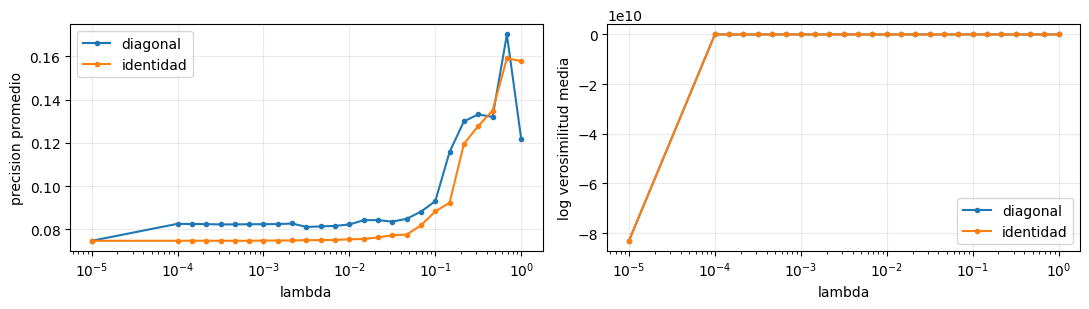

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
for destino, sub in curva.groupby("destino"):
    ax[0].semilogx(np.maximum(sub["lambda"], 1e-5), sub["precision promedio val"], marker="o", ms=3, label=destino)
    ax[1].semilogx(np.maximum(sub["lambda"], 1e-5), sub["log verosimilitud val"], marker="o", ms=3, label=destino)
ax[0].set_xlabel("lambda"); ax[0].set_ylabel("precision promedio"); ax[0].legend()
ax[1].set_xlabel("lambda"); ax[1].set_ylabel("log verosimilitud media"); ax[1].legend()
fig.tight_layout()

**Lo que muestran las graficas.** A la izquierda, la precision promedio en validacion es plana y baja (alrededor de 0,08, apenas sobre el azar) para todo $\lambda$ menor que 0,05, sube con fuerza entre 0,1 y 0,7, alcanza su maximo de 0,17 en $\lambda = 0{,}68$ hacia la diagonal, y vuelve a bajar en $\lambda = 1$ (diagonal pura), que da 0,12. Es exactamente la curva en forma de joroba que predice el compromiso sesgo varianza de la seccion 3.7.3: con poca contraccion la covarianza sobreajusta y el clasificador no generaliza; con contraccion total se pierde la poca estructura de correlacion que si es util. A la derecha, la log verosimilitud media de validacion es de $-8 \times 10^{9}$ en $\lambda = 0$ y salta a valores razonables en cuanto $\lambda$ es positivo: basta una contraccion minima para que la covarianza de la clase de fallo deje de ser singular. Las dos curvas cuentan lo mismo desde dos criterios distintos.

## 9. Comparacion de las tres familias en prueba

El umbral de decision se fija en la probabilidad posterior de 0.5 para esta tabla. La seccion 11 lo mueve segun el costo.

**Que hace esta celda.** Con el $\lambda$ y el destino elegidos en validacion, ajusta las tres familias en entrenamiento y las evalua en prueba, que hasta aqui no se habia tocado. El umbral de decision es log posterior mayor que cero, es decir, posterior de fallo mayor que 0,5. La tabla reporta precision promedio, sensibilidad, especificidad, log verosimilitud media de prueba y saltos de Cholesky.

**Conexion con el libro.** Es la comparacion que la seccion 3.7.3 anticipa: la familia con mas parametros no tiene por que ganar en datos nuevos. Ademas hay dos criterios que pueden discrepar: la log verosimilitud mide que tan bien el modelo describe los datos (ajuste generativo) y la precision promedio mide que tan bien separa las clases (uso discriminativo). Un modelo puede ser mejor en uno y peor en el otro.

In [14]:
LAM = float(mejor["lambda"])
DESTINO = str(mejor["destino"])

modelos = {
    "completa": ajustar(Ztr, ytr, "completa"),
    "diagonal": ajustar(Ztr, ytr, "diagonal"),
    f"contraida lambda {LAM:.4g} hacia {DESTINO}": ajustar(Ztr, ytr, "contraida", lam=LAM, destino=DESTINO),
}

filas = []
puntajes = {}
for nombre, m in modelos.items():
    s = log_posterior(m, Zte)
    puntajes[nombre] = s
    yhat = (s > 0.0).astype(int)
    mc = matriz_confusion(yte, yhat)
    se = sensibilidad_especificidad(mc)
    filas.append({"familia": nombre,
                  "precision promedio": precision_promedio(yte, s),
                  "sensibilidad": se["sensibilidad"],
                  "especificidad": se["especificidad"],
                  "log verosimilitud prueba": log_verosimilitud_media(m, Zte, yte),
                  "saltos de cholesky": max(m[c]["saltos"] for c in (0, 1))})

pd.DataFrame(filas).set_index("familia").round(4)

,precision promedio,sensibilidad,especificidad,log verosimilitud prueba,saltos de cholesky
familia,,,,,
completa,0.0900,0.0,1.0,-1.006335e+11,0
diagonal,0.1370,0.0,1.0,-1.349029e+04,0
contraida lambda 0.6813 hacia diagonal,0.1007,0.0,1.0,-1.199389e+04,0


**Como leer la salida.** Tres observaciones. Primera, con el umbral en 0,5 las tres familias tienen sensibilidad cero: ningun lote de prueba recibe posterior de fallo mayor que 0,5. Con una previa de 6,6 % para el fallo y clases que se solapan, la regla de Bayes casi nunca elige la clase minoritaria; el umbral de la seccion 11 corrige esto. Segunda, la log verosimilitud de prueba de la completa es $-10^{11}$, frente a $-1{,}3 \times 10^4$ de la diagonal y $-1{,}2 \times 10^4$ de la contraida: la covarianza singular de la clase de fallo asigna a los lotes de prueba densidades astronomicamente pequenas, que es la forma numerica del sobreajuste que la seccion 3.7.3 describe. Tercera, en precision promedio la diagonal (0,137) supera a la contraida (0,101) y a la completa (0,090), todas por encima del azar (0,070) pero por poco. El modelo con menos parametros es el que mejor ordena los lotes, y aun asi la senal es debil.

**Que hace esta celda.** Muestra la matriz de confusion de cada familia en prueba con el umbral en 0,5. Con 6,6 % de fallos, la columna "pred fallo" suele ser pequena: la regla de Bayes con previas estimadas favorece la clase mayoritaria salvo que la evidencia sea fuerte. La seccion 11 mueve el umbral segun el costo.

In [15]:
for nombre in modelos:
    display(nombre, matriz_confusion(yte, (puntajes[nombre] > 0.0).astype(int)))

'completa'

,pred conforme,pred fallo
real conforme,294,0
real fallo,22,0


'diagonal'

,pred conforme,pred fallo
real conforme,294,0
real fallo,22,0


'contraida lambda 0.6813 hacia diagonal'

,pred conforme,pred fallo
real conforme,294,0
real fallo,22,0


**Como leer la salida.** Las tres matrices son identicas: 294 conformes bien clasificados, 22 fallos todos omitidos. Es la matriz de un modelo que siempre dice "conforme", que con estas previas es lo que la regla de Bayes con umbral 0,5 produce. La exactitud seria 93 %, lo que ilustra por que la exactitud no sirve como metrica en este problema.

**Que hace esta celda.** Dibuja la curva precision recall de las tres familias en prueba y la linea horizontal del azar (la proporcion de fallos). Cuanto mas arriba y a la derecha, mejor; el numero entre parentesis es el area bajo cada curva.

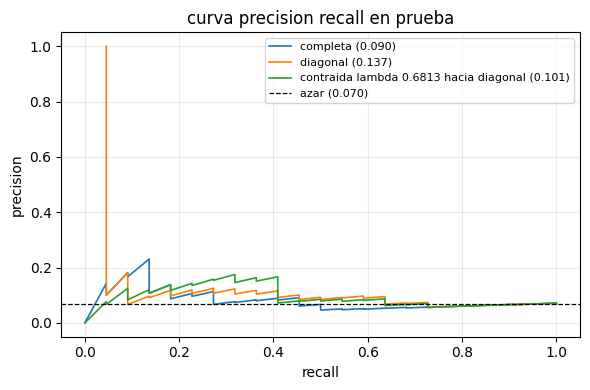

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
for nombre, s in puntajes.items():
    p, r = curva_pr(yte, s)
    ax.plot(r, p, lw=1.2, label=f"{nombre} ({precision_promedio(yte, s):.3f})")
ax.axhline(yte.mean(), color="black", ls="--", lw=0.9, label=f"azar ({yte.mean():.3f})")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_title("curva precision recall en prueba")
ax.legend(fontsize=8)
fig.tight_layout()

**Lo que muestra la grafica.** Las tres curvas se mueven entre 0,05 y 0,25 de precision, muy cerca de la linea del azar en 0,07, y se cruzan varias veces. La diagonal tiene un pico de precision 1,0 con recall 0,05: su lote mejor puntuado es efectivamente un fallo, y eso le da la mayor area. La contraida es la mejor en el tramo de recall entre 0,2 y 0,4, que es la zona util para un sistema de inspeccion (detectar un tercio de los fallos con precision del 15 al 20 %), y la completa esta por debajo de las otras dos casi en todo el rango. La lectura global es que el modelo gaussiano ordena los lotes un poco mejor que el azar, pero no mucho mas, y que las diferencias entre familias son del tamano del ruido de muestreo, como confirma la seccion 12.

## 10. Experimento n frente a d

Se repite el ajuste variando el numero de observaciones de entrenamiento y el numero de variables, tomadas por varianza descendente. La superficie muestra donde cada familia deja de ser estimable.

**Que hace esta celda.** Construye la superficie de error frente a $n$ y $d$. Ordena las variables por varianza descendente, toma las primeras $d$ para $d \in \{10, 25, 50, 100, 200, 400, \text{todas}\}$, submuestrea $n$ lotes de entrenamiento de forma estratificada para $n \in \{100, 200, 400, 600, \text{todos}\}$, ajusta las tres familias en ese subconjunto y evalua la precision promedio en el bloque de prueba completo (con las mismas $d$ columnas). Si Cholesky no lograra factorizar una covarianza, la combinacion quedaria como `NaN`; en la practica el `jitter` minimo permite factorizarlas todas, asi que la superficie no tiene huecos y el efecto de la singularidad se ve en los valores, no en las ausencias.

**Conexion con el libro.** Es el experimento de la seccion 3.7.1 sobre precision, dimension y tamano de muestra. El capitulo explica que, con parametros conocidos, agregar variables nunca empeora el clasificador de Bayes, pero con parametros estimados si puede empeorarlo, porque cada variable nueva agrega parametros que se estiman con los mismos $n$ datos. La tabla permite ver donde cada familia deja de funcionar (la completa cuando $n$ se acerca a $d$ o queda por debajo) y donde agregar variables deja de ayudar.

In [17]:
orden_var = np.argsort(-Ztr.var(axis=0))
REJILLA_D = [10, 25, 50, 100, 200, min(400, Ztr.shape[1]), Ztr.shape[1]]
REJILLA_N = [100, 200, 400, 600, Ztr.shape[0]]
REJILLA_D = sorted(set(REJILLA_D))
REJILLA_N = sorted(set(REJILLA_N))

def submuestra_estratificada(ytr, n, semilla):
    gen = np.random.default_rng(semilla)
    sel = []
    for c in (0, 1):
        pos = np.flatnonzero(ytr == c)
        gen.shuffle(pos)
        k = max(2, int(round(n * np.mean(ytr == c))))
        sel.append(pos[:min(k, len(pos))])
    return np.concatenate(sel)

superficie = []
for tipo, kw in [("completa", {}), ("diagonal", {}),
                 ("contraida", {"lam": LAM, "destino": DESTINO})]:
    for d in REJILLA_D:
        cols = orden_var[:d]
        for n in REJILLA_N:
            sel = submuestra_estratificada(ytr, n, semilla=SEED + n + d)
            m = ajustar(Ztr[np.ix_(sel, cols)], ytr[sel], tipo, **kw)
            if any(m[c]["L"] is None for c in (0, 1)):
                ap = np.nan
            else:
                ap = precision_promedio(yte, log_posterior(m, Zte[:, cols]))
            superficie.append({"familia": tipo, "d": d, "n": n,
                               "precision promedio": ap,
                               "n sobre d": n / d,
                               "saltos": max(m[c]["saltos"] for c in (0, 1))})

superficie = pd.DataFrame(superficie)
superficie.pivot_table(index=["familia", "n"], columns="d", values="precision promedio").round(3)

d                10     25     50     100    200    400    436
familia   n                                                   
completa  100  0.059  0.073  0.095  0.064  0.060  0.074  0.072
          200  0.072  0.085  0.063  0.069  0.079  0.118  0.066
          400  0.098  0.065  0.055  0.061  0.095  0.073  0.075
          600  0.090  0.057  0.063  0.065  0.085  0.092  0.094
          939  0.103  0.050  0.063  0.069  0.078  0.086  0.090
contraida 100  0.063  0.197  0.088  0.091  0.081  0.095  0.120
          200  0.113  0.133  0.151  0.144  0.112  0.172  0.088
          400  0.104  0.092  0.125  0.144  0.153  0.105  0.074
          600  0.079  0.110  0.080  0.202  0.128  0.189  0.129
          939  0.097  0.126  0.141  0.161  0.142  0.102  0.101
diagonal  100  0.072  0.204  0.081  0.113  0.095  0.122  0.066
          200  0.125  0.129  0.156  0.141  0.084  0.218  0.123
          400  0.104  0.104  0.124  0.117  0.192  0.104  0.174
          600  0.083  0.108  0.083  0.136  0.113  0.165  0.174
          939  0.102  0.091  0.100  0.142  0.118  0.158  0.137

**Como leer la salida.** La tabla es ruidosa, y eso es parte del mensaje. En la familia completa casi ningun valor supera 0,10 y varios estan por debajo del azar; en el mapa de calor aparece como el panel mas oscuro. Agregar variables no la mejora porque cada columna nueva agrega parametros que no se pueden estimar, y con $n = 100$ o $200$ y $d = 400$ la covarianza de la clase de fallo es singular sin remedio. En la diagonal y la contraida los mejores valores (alrededor de 0,20) aparecen con $d$ entre 25 y 200, no con las 436 variables completas: es el fenomeno de la seccion 3.7.1, mas variables con los mismos datos puede empeorar el clasificador estimado. Que no haya un patron limpio en $n$ se explica por la varianza del estimador: con 22 fallos en prueba, la precision promedio cambia en varias centesimas por azar, y la seccion 12 lo cuantifica.

**Que hace esta celda.** Dibuja la superficie como tres mapas de calor, uno por familia, con $d$ en el eje horizontal y $n$ en el vertical. Se lee buscando en que direccion crece el color: hacia arriba (mas datos) siempre deberia ayudar; hacia la derecha (mas variables) ayuda solo hasta cierto punto.

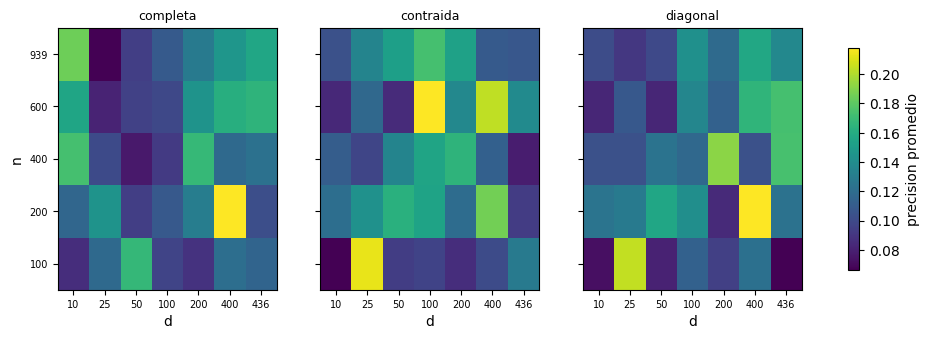

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for a, (fam, sub) in zip(ax, superficie.groupby("familia")):
    tabla = sub.pivot_table(index="n", columns="d", values="precision promedio")
    im = a.imshow(tabla.to_numpy(), aspect="auto", origin="lower", cmap="viridis")
    a.set_xticks(range(len(tabla.columns))); a.set_xticklabels(tabla.columns, fontsize=7)
    a.set_yticks(range(len(tabla.index))); a.set_yticklabels(tabla.index, fontsize=7)
    a.set_title(fam, fontsize=9); a.set_xlabel("d"); a.grid(False)
ax[0].set_ylabel("n")
fig.colorbar(im, ax=ax, shrink=0.85, label="precision promedio")

**Que hace esta celda.** Reordena la misma informacion contra el cociente $n/d$ en escala logaritmica, con una linea vertical en $n/d = 1$. Es la variable que la seccion 3.7.1 senala como determinante: a la izquierda de la linea la covarianza completa es singular por construccion, y las familias restringidas son las unicas que sobreviven.

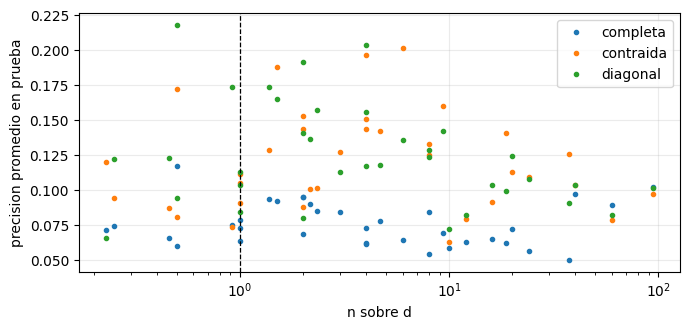

In [19]:
fig, ax = plt.subplots(figsize=(7, 3.4))
for fam, sub in superficie.groupby("familia"):
    sub = sub.sort_values("n sobre d")
    ax.semilogx(sub["n sobre d"], sub["precision promedio"], marker="o", ms=3, ls="none", label=fam)
ax.axvline(1.0, color="black", ls="--", lw=0.9)
ax.set_xlabel("n sobre d"); ax.set_ylabel("precision promedio en prueba"); ax.legend()
fig.tight_layout()

## 11. Umbral sensible al costo

Si omitir un fallo cuesta mucho mas que una falsa alarma, el umbral optimo se desplaza por debajo de 0.5. Se recorre la razon de costos y se reporta el umbral que minimiza el costo esperado en validacion, evaluado despues en prueba.

**Que hace esta celda.** Incorpora el costo de cada tipo de error. `costo` suma `c_fn` por cada fallo omitido y `c_fp` por cada falsa alarma. Para cada razon de costos entre 1 y 100, recorre 400 umbrales sobre la probabilidad posterior de fallo en validacion, elige el que minimiza el costo esperado, y reporta en prueba la sensibilidad, la especificidad y el costo con ese umbral.

**Conexion con el libro.** Es la regla de decision de Bayes con funcion de perdida del capitulo 2: la accion optima minimiza el riesgo condicional, y con dos clases eso equivale a comparar $P(y = 1 \mid x)$ con un umbral $\lambda_{12} / (\lambda_{12} + \lambda_{21})$ en lugar de con 0,5. El cuaderno no calcula el umbral con esa formula sino que lo busca empiricamente en validacion, porque las posteriores del modelo no estan perfectamente calibradas; pero la logica es la misma, y el umbral optimo baja a medida que omitir un fallo se vuelve mas caro.

In [20]:
def costo(yv, yhat, c_fn, c_fp=1.0):
    fn = int(((yv == 1) & (yhat == 0)).sum())
    fp = int(((yv == 0) & (yhat == 1)).sum())
    return c_fn * fn + c_fp * fp

MODELO = modelos[f"contraida lambda {LAM:.4g} hacia {DESTINO}"]
s_va = log_posterior(MODELO, Zva)
s_te = log_posterior(MODELO, Zte)
p_va = 1.0 / (1.0 + np.exp(np.clip(-s_va, -700, 700)))   # acotar evita el desbordamiento en exp
p_te = 1.0 / (1.0 + np.exp(np.clip(-s_te, -700, 700)))

rejilla_umbral = np.linspace(0.001, 0.999, 400)
filas = []
for c_fn in [1, 5, 10, 25, 50, 100]:
    costos = [costo(yva, (p_va > u).astype(int), c_fn) for u in rejilla_umbral]
    u = float(rejilla_umbral[int(np.argmin(costos))])
    mc = matriz_confusion(yte, (p_te > u).astype(int))
    se = sensibilidad_especificidad(mc)
    filas.append({"costo de omitir un fallo": c_fn, "umbral": u,
                  "sensibilidad prueba": se["sensibilidad"],
                  "especificidad prueba": se["especificidad"],
                  "costo en prueba": costo(yte, (p_te > u).astype(int), c_fn)})

pd.DataFrame(filas).round(4)

,costo de omitir un fallo,umbral,sensibilidad prueba,especificidad prueba,costo en prueba
0,1,0.5013,0.0000,1.0000,22.0
1,5,0.5013,0.0000,1.0000,110.0
2,10,0.4937,0.4091,0.7925,191.0
3,25,0.0010,0.4091,0.6633,424.0
4,50,0.0010,0.4091,0.6633,749.0
5,100,0.0010,0.4091,0.6633,1399.0


**Como leer la salida.** Con costo 1 y 5 el umbral optimo queda en 0,50 y no se detecta ningun fallo. Con costo 10 el umbral baja a 0,49 y la sensibilidad sube a 0,41 a cambio de 21 % de falsas alarmas. A partir de costo 25 el umbral se desploma a 0,001: cuando omitir un fallo cuesta 25 veces mas que una falsa alarma, la decision optima es marcar como sospechoso todo lo que tenga una probabilidad minima, y la especificidad baja a 0,66. Que la sensibilidad se quede en 0,41 aunque el umbral baje mas dice que hay fallos a los que el modelo asigna probabilidad practicamente cero: para ellos no hay umbral que ayude, porque el modelo generativo no los distingue de los conformes.

La advertencia de desbordamiento en `exp` que aparecia en esta celda venia de puntajes muy grandes en valor absoluto; se acota el argumento antes de exponenciar, lo que no cambia ningun resultado porque la sigmoide de esos valores ya era 0 o 1 en precision de maquina.

## 12. Estabilidad de la seleccion

Se repite la particion con varias semillas para ver si el lambda elegido y la precision promedio se sostienen o si dependen del corte.

**Que hace esta celda.** Repite todo el proceso (particion, filtrado, imputacion, estandarizacion, eleccion de $\lambda$ en validacion, evaluacion en prueba) con cinco semillas distintas. Para cada una registra el $\lambda$ elegido y la precision promedio de la contraida y de la diagonal en prueba, junto con el azar.

**Por que hace falta.** Con 104 fallos repartidos en tres bloques, la prueba tiene alrededor de veinte. Una metrica calculada sobre veinte casos positivos tiene mucha varianza, y una sola particion puede dar un resultado enganoso por suerte. Repetir la particion es la forma honesta de saber si la conclusion se sostiene o depende del corte.

In [21]:
filas = []
for semilla in [7, 11, 23, 42, 101]:
    a, b, c = particion_estratificada(y, semilla=semilla)
    Xa = X[a]
    f_a = np.isnan(Xa).mean(axis=0)
    d_a = np.array([len(np.unique(Xa[~np.isnan(Xa[:, j]), j])) for j in range(Xa.shape[1])])
    keep = (f_a <= MAX_FALTANTE) & (d_a >= MIN_DISTINTOS)
    med = np.nanmedian(Xa[:, keep], axis=0)

    def prep(bloque):
        Z = X[bloque][:, keep].copy()
        nanmask = np.isnan(Z)
        Z[nanmask] = np.take(med, np.where(nanmask)[1])
        return Z

    Za, Zb, Zc = prep(a), prep(b), prep(c)
    mu_a, sd_a = Za.mean(axis=0), Za.std(axis=0, ddof=0)
    sd_a[sd_a == 0] = 1.0
    Za, Zb, Zc = (Za - mu_a) / sd_a, (Zb - mu_a) / sd_a, (Zc - mu_a) / sd_a

    puntuacion = []
    for lam in LAMBDAS:
        m = ajustar(Za, y[a], "contraida", lam=lam, destino=DESTINO)
        if any(m[k]["L"] is None for k in (0, 1)):
            continue
        puntuacion.append((precision_promedio(y[b], log_posterior(m, Zb)), float(lam)))
    ap_val, lam_op = max(puntuacion)

    m = ajustar(Za, y[a], "contraida", lam=lam_op, destino=DESTINO)
    m_diag = ajustar(Za, y[a], "diagonal")
    filas.append({"semilla": semilla, "d": int(keep.sum()), "lambda elegido": lam_op,
                  "ap validacion": ap_val,
                  "ap prueba contraida": precision_promedio(y[c], log_posterior(m, Zc)),
                  "ap prueba diagonal": precision_promedio(y[c], log_posterior(m_diag, Zc)),
                  "ap azar": float(y[c].mean())})

estabilidad = pd.DataFrame(filas)
estabilidad.round(4)

,semilla,d,lambda elegido,ap validacion,ap prueba contraida,ap prueba diagonal,ap azar
0,7,436,0.6813,0.1702,0.1007,0.1370,0.0696
1,11,436,0.0015,0.1349,0.1080,0.0577,0.0696
2,23,436,0.6813,0.1911,0.1743,0.1617,0.0696
3,42,436,1.0000,0.1768,0.1432,0.1432,0.0696
4,101,436,0.2154,0.1903,0.0704,0.0555,0.0696


**Como leer la salida.** El $\lambda$ elegido salta entre 0,0015 y 1,0 segun la semilla: la validacion, con veinte fallos, no tiene suficiente evidencia para fijar el hiperparametro. La precision promedio en prueba de la contraida va de 0,07 a 0,17 y la de la diagonal de 0,06 a 0,16. Ambas estan casi siempre por encima del azar, pero la diferencia entre ellas cambia de signo de una semilla a otra.

**Que hace esta celda.** Media y desviacion de las tres columnas de la tabla anterior a lo largo de las cinco semillas. Si la desviacion es comparable a la diferencia entre familias, la comparacion no es concluyente.

In [22]:
estabilidad[["ap prueba contraida", "ap prueba diagonal", "ap azar"]].agg(["mean", "std"]).round(4)

,ap prueba contraida,ap prueba diagonal,ap azar
mean,0.1193,0.1110,0.0696
std,0.0402,0.0505,0.0000


**Como leer la salida.** Contraida 0,119 con desviacion 0,040; diagonal 0,111 con desviacion 0,051. La diferencia entre las dos familias (0,008) es cinco veces menor que la desviacion entre particiones. La conclusion honesta es que ambas superan el azar (0,070) y que no se puede afirmar que una sea mejor que la otra con estos datos. Lo que si se sostiene en las cinco semillas es la conclusion cualitativa de la seccion 3.7: las familias restringidas funcionan y la completa no.

## 13. Diagnostico de supuestos

El clasificador gaussiano del capitulo descansa en cuatro hipotesis. Las dos celdas siguientes
comprueban las dos que se pueden medir con estos datos, y las otras dos se evaluan con lo ya
calculado.

**Normalidad condicional por clase.** Se mide con la asimetria y la curtosis de cada variable
conservada en entrenamiento. La celda siguiente muestra que la mitad de las variables esta lejos de
la normal, con colas pesadas y distribuciones sesgadas; para ellas la media y la covarianza son
resúmenes pobres de la densidad real.

**Igualdad o no de covarianzas entre clases.** Con covarianzas separadas la frontera es cuadratica
(caso general de la seccion 2.6); con una covarianza comun es lineal y se estima con todos los datos
juntos. La segunda celda compara ambas versiones en prueba y muestra que la lineal generaliza mejor:
la covarianza propia de la clase de fallo, estimada con 62 lotes, aporta mas varianza de estimacion
que informacion.

**Suficiencia de $n$ en la clase minoritaria.** Es la que fija el limite real, no el $n$ total. La
seccion 7 mostro la covarianza de fallo singular (62 filas para 436 dimensiones), y la seccion 12
mostro que con veinte fallos en validacion el hiperparametro $\lambda$ no se puede fijar de manera
estable. Todo lo demas es consecuencia de este numero.

**Imputacion por mediana.** Sustituir un faltante por la mediana introduce masa en un punto y reduce
artificialmente la varianza de las columnas mas incompletas, lo que a su vez altera la covarianza
estimada. Con 4,5 % de faltantes el efecto es moderado, pero es una desviacion mas del modelo del
capitulo, que supone datos completos. La alternativa coherente con el capitulo es el EM de la
seccion 3.9, que estima $\mu$ y $\Sigma$ integrando sobre los faltantes en lugar de rellenarlos.

**Que hace esta celda.** Calcula la asimetria (tercer momento estandarizado) y el exceso de curtosis (cuarto momento menos tres) de cada variable conservada en entrenamiento, dibuja sus histogramas y cuenta cuantas variables tienen asimetria mayor que 2 o curtosis mayor que 10 en valor absoluto. Para una normal ambos valen cero.

**Conexion con el libro.** Es el diagnostico de la hipotesis de forma parametrica de la seccion 3.1: el capitulo entero supone que $p(x \mid c)$ es normal. Variables con colas muy pesadas o con asimetria fuerte violan esa hipotesis, y en ellas la media y la covarianza estimadas describen mal la densidad real, aunque el MLE las calcule sin queja.

variables con asimetria en valor absoluto mayor que 2    222
variables con exceso de curtosis mayor que 10            221
total                                                    436
dtype: int64

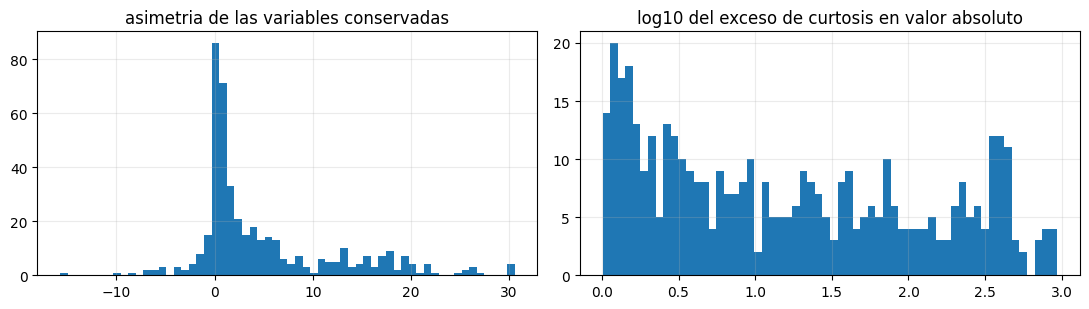

In [23]:
def asimetria(Z):
    d = Z - Z.mean(axis=0)
    s = Z.std(axis=0, ddof=0)
    s[s == 0] = 1.0
    return np.mean((d / s) ** 3, axis=0)

def curtosis(Z):
    d = Z - Z.mean(axis=0)
    s = Z.std(axis=0, ddof=0)
    s[s == 0] = 1.0
    return np.mean((d / s) ** 4, axis=0) - 3.0

diag = pd.DataFrame({"asimetria": asimetria(Ztr), "exceso de curtosis": curtosis(Ztr)})

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(diag["asimetria"], bins=60); ax[0].set_title("asimetria de las variables conservadas")
ax[1].hist(np.log10(np.abs(diag["exceso de curtosis"]) + 1), bins=60)
ax[1].set_title("log10 del exceso de curtosis en valor absoluto")
fig.tight_layout()

pd.Series({"variables con asimetria en valor absoluto mayor que 2": int((diag["asimetria"].abs() > 2).sum()),
           "variables con exceso de curtosis mayor que 10": int((diag["exceso de curtosis"] > 10).sum()),
           "total": len(diag)})

**Como leer la salida.** 222 de las 436 variables tienen asimetria mayor que 2 y 221 tienen exceso de curtosis mayor que 10. La mitad de las variables esta lejos de la normalidad: colas pesadas y distribuciones sesgadas que la media y la covarianza describen mal. Esto explica en parte la senal debil de todo el cuaderno y sugiere, como paso siguiente, transformar las variables (logaritmo, rangos) antes de aplicar el modelo gaussiano, o reconocer que la familia parametrica correcta no es la normal.

**Que hace esta celda.** Compara dos versiones del mismo modelo contraido: con una covarianza por clase (frontera cuadratica) y con una covarianza comun, `S_pool`, que es el promedio ponderado por $n_c - 1$ de las dos (frontera lineal). Evalua la precision promedio de ambas en prueba.

**Conexion con el libro.** Es la distincion de la seccion 2.6 entre el caso $\Sigma_i = \Sigma$ (discriminante lineal) y el caso $\Sigma_i$ arbitrario (discriminante cuadratico), vista desde el capitulo 3: la covarianza comun se estima con los datos de las dos clases juntas, asi que tiene la mitad de parametros por dato y menos varianza. Si la frontera lineal rinde igual o mejor, es evidencia de que la covarianza separada por clase estaba sobreajustando, sobre todo la de la clase de fallo, que solo tiene unas sesenta filas en entrenamiento.

In [24]:
comun = ajustar(Ztr, ytr, "contraida", lam=LAM, destino=DESTINO)
S_pool = sum((comun[c]["n"] - 1) * comun[c]["S"] for c in (0, 1)) / (len(ytr) - 2)
L_pool, _ = cholesky_segura(S_pool)

lineal = {c: {"mu": comun[c]["mu"], "S": S_pool, "L": L_pool,
              "log_prior": comun[c]["log_prior"], "n": comun[c]["n"], "saltos": 0}
          for c in (0, 1)}

pd.Series({"ap prueba frontera cuadratica": precision_promedio(yte, log_posterior(comun, Zte)),
           "ap prueba frontera lineal": precision_promedio(yte, log_posterior(lineal, Zte)),
           "ap azar": float(yte.mean())}).round(4)

ap prueba frontera cuadratica    0.1007
ap prueba frontera lineal        0.1741
ap azar                          0.0696
dtype: float64

**Como leer la salida.** La frontera lineal (covarianza comun) da 0,174 frente a 0,101 de la cuadratica. Estimar una sola covarianza con las 939 filas en lugar de una por clase, donde la de fallo solo dispone de 62, mejora el ordenamiento de los lotes. Es exactamente el mecanismo de la seccion 3.7.3: menos parametros por dato, menos varianza de estimacion, mejor generalizacion, aunque el modelo sea "menos flexible". Junto con la tabla de estabilidad, sugiere que la version con covarianza comun deberia ser el modelo de referencia de este problema.

## 14. Limitaciones y pregunta de investigacion

**Fuga de informacion.** El riesgo principal en este problema es que alguna decision use la variable
objetivo o los bloques de validacion y prueba para filtrar columnas, imputar o escalar, lo que
inflaria el resultado. En este cuaderno el filtrado, la mediana de imputacion y la estandarizacion
salen unicamente del bloque de entrenamiento, y $\lambda$ se escoge en validacion. La seccion 12
muestra ademas que el resultado se repite, con su variabilidad, en cinco particiones distintas.

**Interpretacion.** Un lote marcado como fallo por el modelo es un lote cuya composicion de variables
de proceso es improbable bajo la clase conforme. Eso no identifica la causa fisica de la falla ni el
paso del proceso responsable.

**Lo que el cuaderno establece.** El modelo gaussiano generativo de las secciones 3.2 y 2.6 se puede
ajustar y evaluar de forma limpia en 436 dimensiones, y el experimento reproduce las tres
conclusiones de la seccion 3.7: la covarianza completa es singular y sobreajusta cuando $n$ es
comparable a $d$; la contraccion y la diagonal la superan en datos nuevos aunque tengan mas sesgo;
y agregar variables no mejora el clasificador estimado. La senal util del modelo es modesta (precision
promedio entre 0,10 y 0,17 frente a 0,07 del azar), y la covarianza comun entre clases es la version
que mejor generaliza.

**Pregunta de investigacion futura.** La mitad de las variables de SECOM no es normal y el modelo
del capitulo las trata como si lo fueran. La pregunta que se abre es cuanto de la senal se recupera
si, antes del modelo gaussiano, se lleva cada variable a una escala mas cercana a la normalidad (por
ejemplo con una transformacion de potencia aprendida en entrenamiento) y si se reemplaza la
imputacion por mediana por el EM de la seccion 3.9, que estima la covarianza sin rellenar faltantes.
La hipotesis es que ambas correcciones mueven el modelo hacia sus supuestos y que la mejora en
precision promedio sera mayor que la diferencia entre familias de covarianza, que aqui resulto
indistinguible del ruido de muestreo.